In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")

In [6]:
G = nx.DiGraph()

for _, row in df.iterrows():
    source = row['group_A']
    target = row['group_B']
    
    # Add nodes
    G.add_node(source)
    G.add_node(target)
    
    # Add edges by type
    if row['merge'] == 1:
        G.add_edge(source, target, event='merge', color='blue')
        
    if row['split'] == 1:
        G.add_edge(source, target, event='split', color='red')
        
    if row['expansion'] == 1:
        G.add_edge(source, target, event='expansion', color='orange')

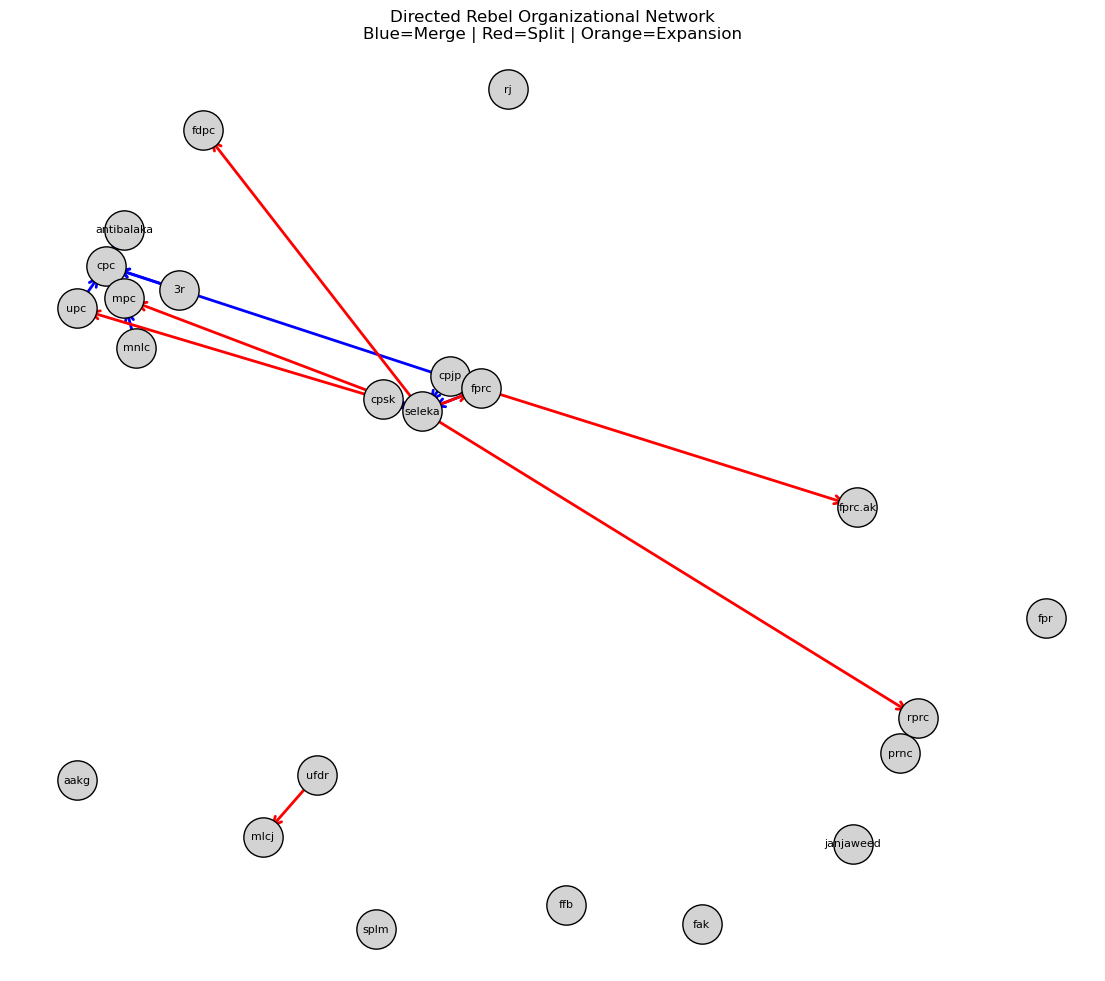

In [7]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos,
                       node_size=800,
                       node_color="lightgray",
                       edgecolors="black")

# Draw edges by color
for u, v, data in G.edges(data=True):
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        edge_color=data['color'],
        arrows=True,
        arrowstyle='->',
        arrowsize=15,
        width=2
    )

# Labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Directed Rebel Organizational Network\nBlue=Merge | Red=Split | Orange=Expansion")
plt.axis("off")
plt.show()

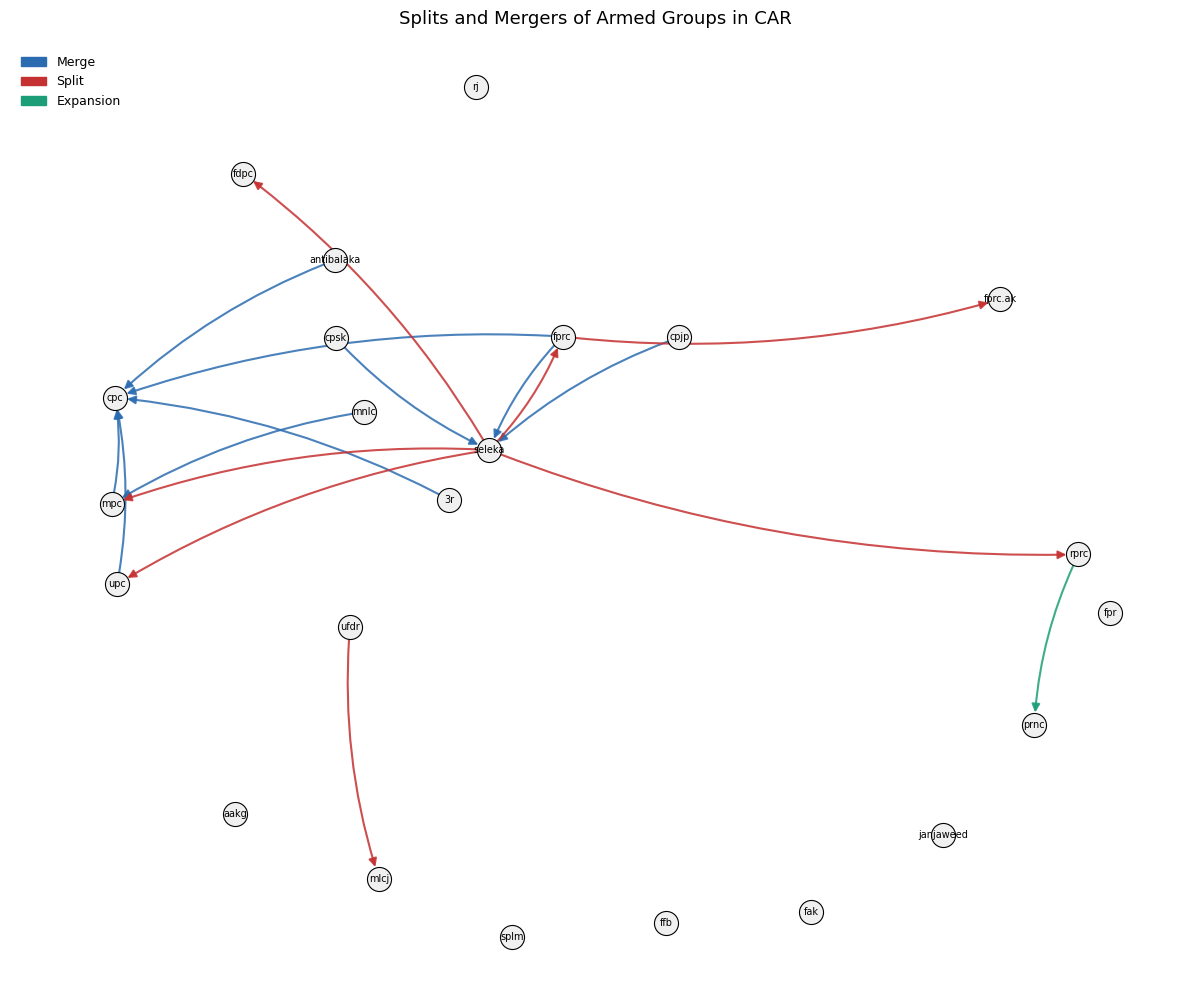

In [10]:
plt.figure(figsize=(12, 10))

# Better layout: more spacing between nodes
pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)

# -------------------
# Draw Nodes (smaller & cleaner)
# -------------------
nx.draw_networkx_nodes(
    G, pos,
    node_size=300,
    node_color="#f0f0f0",
    edgecolors="black",
    linewidths=0.8
)

# -------------------
# Separate edges by type
# -------------------
merge_edges = [(u, v) for u, v, d in G.edges(data=True) if d['event'] == 'merge']
split_edges = [(u, v) for u, v, d in G.edges(data=True) if d['event'] == 'split']
exp_edges   = [(u, v) for u, v, d in G.edges(data=True) if d['event'] == 'expansion']

# Draw edges with slight curvature
nx.draw_networkx_edges(
    G, pos,
    edgelist=merge_edges,
    edge_color="#2b6cb0",
    width=1.5,
    arrows=True,
    arrowsize=12,
    connectionstyle='arc3,rad=0.1',
    alpha=0.85
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=split_edges,
    edge_color="#c53030",
    width=1.5,
    arrows=True,
    arrowsize=12,
    connectionstyle='arc3,rad=0.1',
    alpha=0.85
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=exp_edges,
    edge_color="#1b9e77",
    width=1.5,
    arrows=True,
    arrowsize=12,
    connectionstyle='arc3,rad=0.1',
    alpha=0.85
)

# -------------------
# Labels (smaller, clean)
# -------------------
nx.draw_networkx_labels(
    G, pos,
    font_size=7,
    font_family="sans-serif"
)

# -------------------
# Legend
# -------------------
legend_elements = [
    mpatches.Patch(color="#2b6cb0", label="Merge"),
    mpatches.Patch(color="#c53030", label="Split"),
    mpatches.Patch(color="#1b9e77", label="Expansion")
]

plt.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False,
    fontsize=9
)

plt.title(
    "Splits and Mergers of Armed Groups in CAR",
    fontsize=13,
    pad=15
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "/Users/samqiu/Desktop/triad_datacollecting-main/splits_mergers_car.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()